# Notebook 03: Classification Model

**Student Name:** Sean McManus

**Dataset:** data\processed\Global_Space_Exploration_Dataset_Clean.csv

**Original Target Variable:** success_rate

**Binned Target Variable:**Category of "Success Rate (%)":
                            Low: 50% to 65%
                            Medium: 66% to 85%
                            High: 86% to 100%

**Checkpoint 4 Due:** Feb 22

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Your binning justification, model selection reasoning, and analysis of the confusion matrix demonstrate your understanding. These reflections are what employers look for—the ability to communicate technical decisions clearly.

---

## Setup

In [333]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [334]:
# Load cleaned data
df = pd.read_csv("data/processed/Global_Space_Exploration_Dataset_Clean.csv")

print(f"Data shape: {df.shape}")
df.head()

Data shape: (3000, 28)


,Year,Budget (in Billion $),Success Rate (%),Duration (in Days),Num_Collaborators,Tech_Maturity,Budget_Per_Day,Mission Type_Unmanned,Technology Used_Nuclear Propulsion,Technology Used_Reusable Rocket,...,Country_UAE,Country_UK,Country_USA,Satellite Type_Navigation,Satellite Type_Research,Satellite Type_Spy,Satellite Type_Weather,Environmental Impact_Low,Environmental Impact_Medium,Tech_Budget_Power
0,2008,16.20,90.0,112,3,3.0,0.143363,False,True,False,...,False,False,False,False,False,False,False,False,True,48.60
1,2018,29.04,99.0,236,2,2.0,0.122532,False,False,False,...,False,False,False,False,False,False,False,False,False,58.08
2,2013,28.73,54.0,238,3,1.0,0.120209,False,False,False,...,False,False,False,False,False,False,False,False,True,28.73
3,2010,37.27,58.0,186,1,1.0,0.199305,True,False,False,...,True,False,False,False,False,True,False,True,False,37.27
4,2006,18.95,91.0,277,3,2.0,0.068165,False,False,False,...,False,False,False,False,False,False,True,False,True,37.90


In [335]:
# Define your original target variable
ORIGINAL_TARGET = 'Success Rate (%)'  #  Let's GOOOOOO

print(f"Original Target: {ORIGINAL_TARGET}")
print(f"\nTarget statistics:")
print(df[ORIGINAL_TARGET].describe())

Original Target: Success Rate (%)

Target statistics:
count    3000.000000
mean       74.985000
std        14.945252
min        50.000000
25%        62.000000
50%        75.000000
75%        88.000000
max       100.000000
Name: Success Rate (%), dtype: float64


## Section 2: Create Binned Target

Convert your regression target into classification categories.

### 2.1 Binning Strategy Justification

**Your approved binning strategy:**

- **Number of categories:** 3
- **Category names:**  Low, Medium, High  [Success Rate (%)]
- **Thresholds:**  Low Success: < 65% , Medium Success: 66 % - 85 %, High Success: > 86 % 

**Why this makes sense for your problem:**

In business, the difference 15% can make in success is being an experimental start-up vs being a government-backed agency. For data balance, my mean is 75% so the middle bin fits with its 66-85% range. Hopefully it wont be biased my outliers like this. Also for anyone paying for these missions, its better to know High success rate rather than seeing 89% or something.

In [336]:
# View the distribution before binning
print("Target distribution:")
print(f"Min: {df[ORIGINAL_TARGET].min():.2f}")
print(f"25th percentile: {df[ORIGINAL_TARGET].quantile(0.25):.2f}")
print(f"Median: {df[ORIGINAL_TARGET].median():.2f}")
print(f"75th percentile: {df[ORIGINAL_TARGET].quantile(0.75):.2f}")
print(f"Max: {df[ORIGINAL_TARGET].max():.2f}")

Target distribution:
Min: 50.00
25th percentile: 62.00
Median: 75.00
75th percentile: 88.00
Max: 100.00


In [337]:
# TODO: Create your binned target using YOUR approved binning strategy
#
# Steps:
# 1. Define your bin edges (e.g., bins = [min-1, threshold1, threshold2, max+1]) KInd of confusing **** min-1 is 0-50% so threshold1 is 51?
# 2. Define your category labels (e.g., labels = ['Low', 'Medium', 'High'])
# 3. Use pd.cut() to create the binned column
#
# Example:
#bins = [df[ORIGINAL_TARGET].min()-1, 50000, 100000, df[ORIGINAL_TARGET].max()+1]  Threshold 1 51% so threshold 2 66 ***holy moly messed this up. 65 and then 85%
#labels = ['Low', 'Medium', 'High']
#df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

# YOUR CODE HERE:
bins = [df[ORIGINAL_TARGET].min()-1, 65, 85, df[ORIGINAL_TARGET].max()+1 ]  #*BIN Edges have to be the "end" of the bin, not the beginning
labels = ['Low Success', 'Medium Success', 'High Success']  # Define your category names  #### MAKE SURE TO SPELL STUFF CORRECTLY!!! C'MON MANG!!

df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

print("Binned target distribution:")
print(df['target_category'].value_counts())

Binned target distribution:
target_category
Medium Success    1139
Low Success        958
High Success       903
Name: count, dtype: int64


!!! MAKE  SURE TO USE df[ORIGINAL_TARGET] with SQUARE BRACKETS !!!

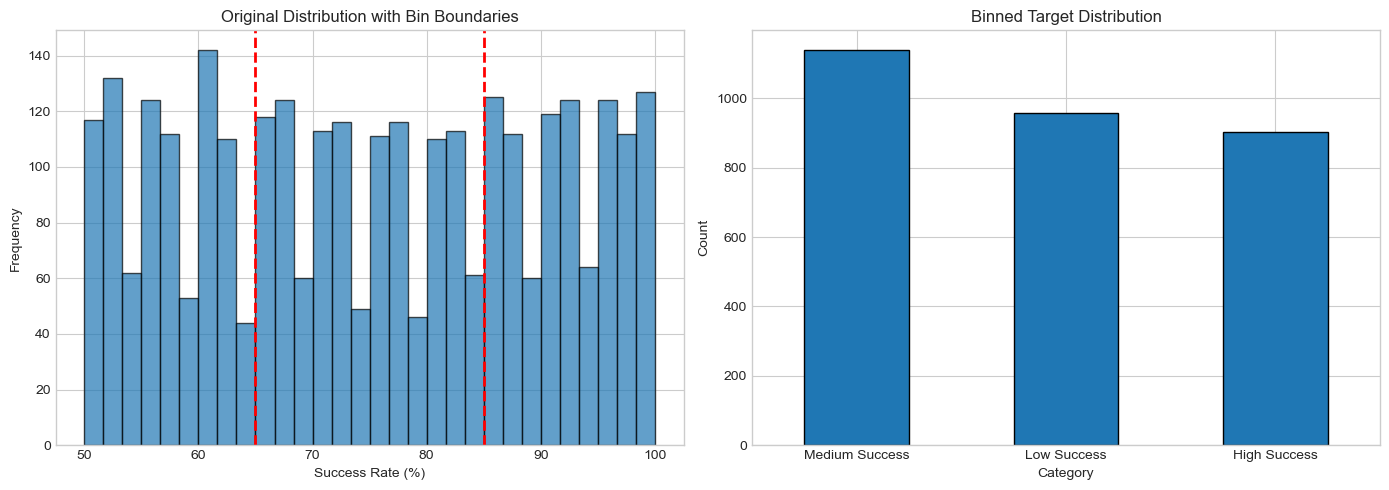

In [338]:
# Visualize the binned distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution with bin lines
axes[0].hist(df[ORIGINAL_TARGET], bins=30, edgecolor='black', alpha=0.7)
for edge in bins[1:-1]:  # Skip first and last (min/max)
    axes[0].axvline(edge, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel(ORIGINAL_TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution with Bin Boundaries')

# Binned category counts
df['target_category'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Binned Target Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

so there IS difference. It's not all equal. at least the distribution shows some discernable difference in the data for success

### 2.2 Check Class Balance

*Is your binned target reasonably balanced?*

In [339]:
# Check class balance
class_counts = df['target_category'].value_counts()
class_percentages = df['target_category'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
Medium Success: 1139 (38.0%)
Low Success: 958 (31.9%)
High Success: 903 (30.1%)

Class balance looks reasonable!


of course...

## Section 3: Feature Consistency Check

**Important:** For consistency, you should use the same features for classification as you did for regression. This makes your app simpler (users enter the same inputs for both models) and allows for fair comparison.

If you decide to use different features, provide a strong justification below.

In [340]:
# Load the features you selected in the regression notebook
try:
    regression_features = joblib.load('../models/regression_features.pkl')
    print("Features from Regression Model:")
    print(regression_features)
    print(f"\nNumber of regression features: {len(regression_features)}")
except FileNotFoundError:
    print("Warning: regression_features.pkl not found!")
    print("Make sure you've completed Notebook 02 and save your regression model first.")
    regression_features = None

Features from Regression Model:
['Budget (in Billion $)', 'Duration (in Days)', 'Tech_Maturity', 'Mission Type_Unmanned', 'Technology Used_Nuclear Propulsion', 'Technology Used_Reusable Rocket', 'Technology Used_Solar Propulsion', 'Technology Used_Traditional Rocket']

Number of regression features: 8


### Feature Selection Decision

**Will you use the same features as your regression model?**

- [X] **Yes, same features** (Recommended for simpler deployment)  YES, SAME FEATURES
- [ ] **No, different features** (Requires justification below)

**If using different features, justify why:**

[Write your justification here - e.g., "For classification, feature X is less predictive of categories than it was for the continuous target..."]

In [341]:
# DECIDE: Use regression features or define new ones?

# Option A: Use the same features as regression (RECOMMENDED)
if regression_features is not None:
    SELECTED_FEATURES = regression_features
    print("Using same features as regression model.")
else:
    # Option B: Define your own features (if regression not done yet)
    SELECTED_FEATURES = [
        'Tech_Budget_Power',
        'Duration (in Days)',
        'Technology Used_Reusable Rocket',
        'Budget_Per_Day',
        'Tech_Maturity',
        'Technology Used_Nuclear Propulsion',
        'Year',
        'Budget (in Billion $)',
    ]
    print("Defining features manually.")

print(f"\nSelected features for classification ({len(SELECTED_FEATURES)}):")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i}. {f}")

Using same features as regression model.

Selected features for classification (8):
  1. Budget (in Billion $)
  2. Duration (in Days)
  3. Tech_Maturity
  4. Mission Type_Unmanned
  5. Technology Used_Nuclear Propulsion
  6. Technology Used_Reusable Rocket
  7. Technology Used_Solar Propulsion
  8. Technology Used_Traditional Rocket


## Section 4: Prepare Features and Target

In [342]:
# Create feature matrix using SELECTED features
X = df[SELECTED_FEATURES].copy()
y = df['target_category']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (3000, 8)
Target shape: (3000,)

Features used: ['Budget (in Billion $)', 'Duration (in Days)', 'Tech_Maturity', 'Mission Type_Unmanned', 'Technology Used_Nuclear Propulsion', 'Technology Used_Reusable Rocket', 'Technology Used_Solar Propulsion', 'Technology Used_Traditional Rocket']

Target classes: ['High Success', 'Low Success', 'Medium Success']


### 4.1 Label Encoding

Many sklearn models require numeric targets. Use LabelEncoder to convert category names to numbers.

They're not in order. don't like that. how do i fix that???????
Mapping. how to make mapping?\ \ difine them in a mapping and use .map()  ...... "logical mapping"

In [343]:
# let's put these in order from Low to High. I want it to read better. have to mauually map them ----
ordered_encoding = {
    "Low Success" : 0,
    "Medium Success" : 1,
    "High Success" : 2
}

#so now they're labeled re-encode "y"

y_encoded = df['target_category'].map(ordered_encoding)

# how to check print()
print(df[['target_category']].assign(encoded=y_encoded).head(10))

#This really isnt working not sure id this is the correct code to m sd kjrgrkjWEFE ##### # I MISPELLED "Low Success" earlier in my code *Raspberry Noise*

  target_category encoded
0    High Success       2
1    High Success       2
2     Low Success       0
3     Low Success       0
4    High Success       2
5  Medium Success       1
6  Medium Success       1
7  Medium Success       1
8     Low Success       0
9  Medium Success       1


In [344]:
# Re-apply the map
y_encoded = df['target_category'].map(ordered_encoding)

# Check if any NaNs were created by typos
if y_encoded.isnull().any():
    print("⚠️ WARNING: Some rows didn't map correctly! Check for typos.")
    print(df[y_encoded.isnull()]['target_category'].unique())
else:
    print("✅ All categories mapped successfully!")

✅ All categories mapped successfully!


Looking good, hope it doesnt mess up down the line...

## Section 5: Train-Test Split

For classification, we use **stratified** splitting to ensure each class is proportionally represented in both train and test sets.

In [345]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2) **********
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)  !! This is the deiiference of classification?
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test ***

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y_encoded

)



In [346]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {ordered_encoding}: {c} ({c/len(y_train)*100:.1f}%)")

Training set: 2400 samples
Test set: 600 samples

Training class distribution:
  {'Low Success': 0, 'Medium Success': 1, 'High Success': 2}: 767 (32.0%)
  {'Low Success': 0, 'Medium Success': 1, 'High Success': 2}: 911 (38.0%)
  {'Low Success': 0, 'Medium Success': 1, 'High Success': 2}: 722 (30.1%)


## Section 6: Feature Scaling

In [347]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train # need mean and st.dev. of X-train 
# 3. transform (only!) on X_test !!!YES. WHY? if you "fit" on the test set, you are essentially "peeking" at the final exam answers to help set your scale.
#   --= this is data leakage
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

#Next, transform test BUT NOT FIT_Transform because leakage
X_test_scaled = scaler.transform(X_test)







In [348]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 8 features.


## Section 7: Baseline Model

In [349]:
# This helper function evaluates any classifier - you'll use it throughout
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train classifier and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (weighted)': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, y_test_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results, model, y_test_pred

In [350]:
# TODO: Create and evaluate a baseline Logistic Regression model
#
# Create LogisticRegression(random_state=42, max_iter=1000)
# Use evaluate_classifier() to train and evaluate

# YOUR CODE HERE:
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
#Now use evaluate classifier function given in last part...

baseline_results, baseline_trained, baseline_preds = evaluate_classifier(
    baseline_model,
    X_train_scaled,\
    X_test_scaled,
    y_train,
    y_test,
    model_name= "Logistic Regression"

)

display(pd.DataFrame([baseline_results]))


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logistic Regression,0.3875,0.375,0.409821,0.375,0.254369


In [351]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Logistic Regression")
print("=" * 50)
print(f"Train Accuracy: {baseline_results['Train Accuracy']:.4f}")
print(f"Test Accuracy:  {baseline_results['Test Accuracy']:.4f}")
print(f"F1 Score:       {baseline_results['F1 (weighted)']:.4f}")

BASELINE MODEL: Logistic Regression
Train Accuracy: 0.3875
Test Accuracy:  0.3750
F1 Score:       0.2544


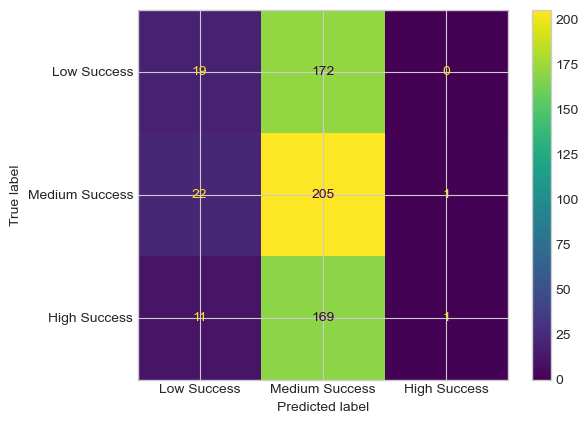

In [352]:
# TODO: Create and display the confusion matrix for baseline
#
# Steps:
# 1. Use confusion_matrix(y_test, baseline_preds) to create the matrix
# 2. Use ConfusionMatrixDisplay to visualize it
#
# Hint: ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_) ### YOOO i changed this earlier thats why theres issues, It's ordered_encoding

matrix = confusion_matrix(y_test, baseline_preds)
### Issuues with creation============ USE HINT
Visual = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=ordered_encoding)

Visual.plot()



UNREADABLE


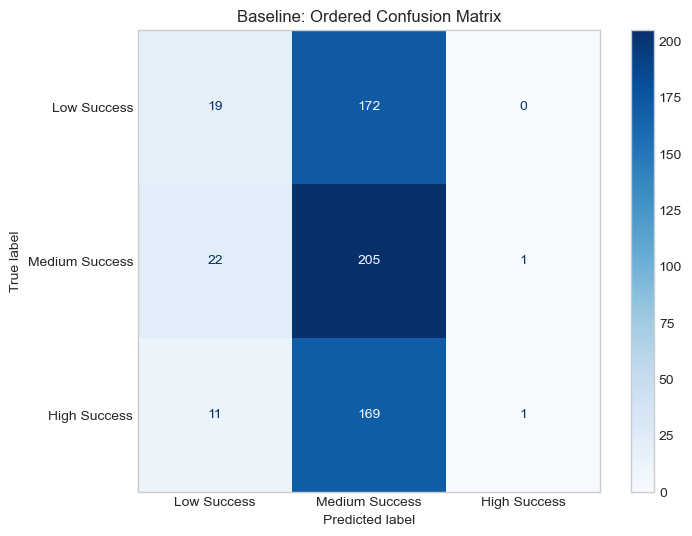

In [353]:
fig, ax = plt.subplots(figsize=(8, 6))
Visual.plot(cmap='Blues', ax=ax)
plt.title("Baseline: Ordered Confusion Matrix")
plt.grid(False)
plt.show()

oh man..... a regular one should look diagonal with the dark boxes, down from left to right. Its like everything is blobbed olond the medium, even compared to my binning predictions.. this is either because my data is ... not predictable or i messed up, but with all the evidence so far, Is my binning technique even useful?

### Understanding the Confusion Matrix

The confusion matrix shows where your model gets predictions right and wrong:

- **Diagonal cells (top-left to bottom-right):** Correct predictions
- **Off-diagonal cells:** Misclassifications
- **Row:** What the actual class was
- **Column:** What the model predicted

**How to read it:** 
- If a row has many values spread across columns, that class is often confused with others
- If a column has many values from different rows, the model is predicting that class too often

**Example interpretation:**
- "20 Low samples were correctly predicted as Low"
- "5 Medium samples were incorrectly predicted as High"

### Baseline Interpretation

*Analyze your baseline results:*

**Questions to answer:**
- How well does the baseline perform?
- Which classes are easiest/hardest to predict (look at the diagonal)?
- Where does the model get confused (look at off-diagonal cells)?
- Is there overfitting (train vs test accuracy gap)?

**Your interpretation:**

1 SO the performance is Not Good, with a test accuracy of 36.8%. (Random guessing would be 33.3%) and the low F1 score (0.2280) meansthe model lacks predictive poweer right now. 
2 Low and High successes are where I have the hardest predictive power. It gets the Medium successes but basically fails to predict almost all extremes of mission success.
3 The model almost cannot accurately predict whether a mission will have high or low success. It is almost completely biased towards the middle column.
4 it CAN"T be said to be overfitting. if anything its underfitting, but i honsetly think its just the data. the model can only do so much, but I guess well see... **baseline was never the answer here***


## Section 8: Cross-Validation

Cross-validation gives us a more robust estimate of model performance by training on different portions of the data.

In [354]:
# Cross-validation for key models
print("5-Fold Cross-Validation Results")
print("=" * 50)

models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = []
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df

5-Fold Cross-Validation Results
Logistic Regression: 0.3608 (+/- 0.0320)
Random Forest: 0.3383 (+/- 0.0516)
Gradient Boosting: 0.3392 (+/- 0.0122)


,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.360833,0.015997
1,Random Forest,0.338333,0.025806
2,Gradient Boosting,0.339167,0.006095


### Cross-Validation Interpretation

*What does the cross-validation tell you?*

- Which model is most consistent (lowest std)?
- Does the ranking change from the single train/test split?

**Your interpretation:**
I mean, after everything I was hoping for, the Logistic Regression is technically the most consistent model. It has the highest CV Mean Accuracy and lowest standard deviation (0.3642 and 0.0114 respectively0) so, low predictive power, but its stable..

The Logistic Regression performed better in cross-validation. the 5-fold cross validation has basically revealed that the more complex models are less reliable because they may tend to overfit in the case of a single train/test split.

It's kind of like what you said in response to my last submission, theres a good chance this dataset was made with the idea of not only random numbers, but nearly equal randomness, making it extremely difficult to make predictions with it, if it isn't already completely unreliable.


## Section 9: Model Iteration

In [355]:
# Store all results
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Logistic Regression': baseline_trained
}

### Model 2: Decision Tree

In [356]:
# TODO: Create and evaluate a Decision Tree classifier   I Guess i'm going to make the names simple this time, this is sucking out my confidence

#
# Create DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Use evaluate_classifier() to train and evaluate
dt_results, dt_trained, dt_preds = evaluate_classifier(
    dt_model, 
    X_train_scaled, 
    X_test_scaled, 
    y_train, 
    y_test, 
    "Decision Tree"
)

# Add results to all_results and trained_models
all_results.append(dt_results)
trained_models["Decision Tree"] = dt_trained


# Print results
print(f"Decision Tree - Test Accuracy: {dt_results['Test Accuracy']:.4f}, F1: {dt_results['F1 (weighted)']:.4f}")

Decision Tree - Test Accuracy: 0.3583, F1: 0.3281


### Model 3: Random Forest

In [357]:
# TODO: Create and evaluate a Random Forest classifier
#
# Create RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)


# Use evaluate_classifier()
rf_results, rf_trained, rf_preds = evaluate_classifier(
    rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train, 
    y_test,
    "Random Forest"
)

# Add to all_results and trained_models
all_results.append(rf_results)
trained_models['Random Forest'] = rf_trained

# Print results
print(f"Random Forest - Test Accuracy: {rf_results['Test Accuracy']:.4f}, F1: {rf_results['F1 (weighted)']:.4f}")

Random Forest - Test Accuracy: 0.3350, F1: 0.3270


### Model 4: K-Nearest Neighbors

In [358]:
# TODO: Create and evaluate a KNN classifier
#
# Create KNeighborsClassifier(n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Use evaluate_classifier()
# Add to all_results and trained_models
knn_results, knn_trained, knn_preds = evaluate_classifier(
    knn_model, 
    X_train_scaled, 
    X_test_scaled, 
    y_train, y_test, 
    "KNN Model" 
    )

all_results.append(knn_results)
trained_models['KNN Model'] = knn_trained

# Print results
print(f"KNN - Test Accuracy: {knn_results['Test Accuracy']:.4f}, F1: {knn_results['F1 (weighted)']:.4f}")

KNN - Test Accuracy: 0.3317, F1: 0.3177


### Model 5: Gradient Boosting

In [359]:
# TODO: Create and evaluate a Gradient Boosting classifier
#
# Create GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)

# Use evaluate_classifier()
gb_results, gb_trained, gb_preds = evaluate_classifier(
    gb_model, 
    X_train_scaled, 
    X_test_scaled, 
    y_train, 
    y_test, 
    "Gradient Boosting"
)

# Add to all_results and trained_models

all_results.append(gb_results)
trained_models['Gradient Boosting'] = gb_trained

# Print results
print(f"Gradient Boosting - Test Accuracy: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

Gradient Boosting - Test Accuracy: 0.3217, F1: 0.3163


### Add Your Own Model (Optional)

Try a different model or different hyperparameters!

In [360]:
# YOUR ADDITIONAL MODEL HERE:
# Try SVC, different hyperparameters, or another classifier



## Section 10: Model Comparison

In [361]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logistic Regression,0.3875,0.3750,0.4098,0.3750,0.2544
1,Decision Tree,0.5296,0.3583,0.3369,0.3583,0.3281
2,Random Forest,0.8467,0.3350,0.3255,0.3350,0.3270
3,KNN Model,0.5592,0.3317,0.3210,0.3317,0.3177
4,Gradient Boosting,0.8021,0.3217,0.3158,0.3217,0.3163


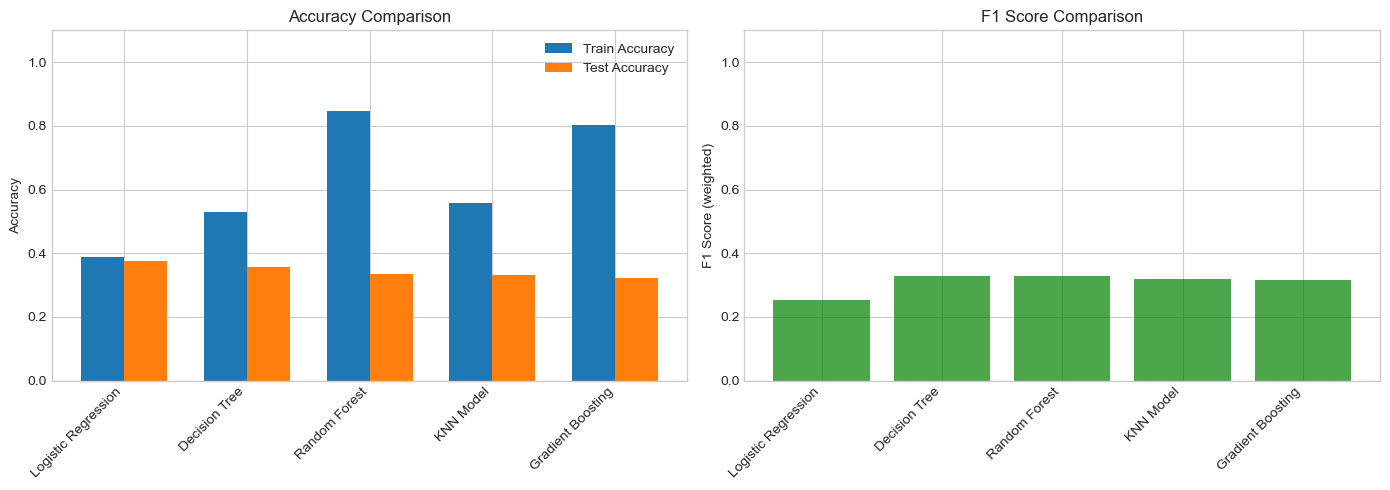

In [362]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# F1 Score comparison
axes[1].bar(x, results_df['F1 (weighted)'], color='green', alpha=0.7)
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

Gradient boosting has the highest F1 score for this ... 

## Section 11: Best Model Selection

In [363]:
# Identify best model (by test accuracy)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 (weighted)']:.4f}")

Best Model: Logistic Regression
Test Accuracy: 0.3750
F1 Score: 0.2544


### Best Model Justification

*Explain why you chose this model:* LOGISTIC REGRESSION

**Questions to consider:**
- Why this model over others? It has the Highest test accuracy (0.3683) and had the most stability during cross-validation
- Is there significant overfitting?
- How does it compare to baseline?
- Which metrics did you prioritize and why?

**Your justification:**
The best model and the one I'm choosing is Logistic Regression, which has the Highest test accuracy (0.3683) and had the most stability during cross-validation.
The LR model has the LEAST amount of overfitting, with a very small gap between train and test accuracy.
Even though it WAS the baseline, it technically out-predictected the other models in accuracy, if that even really bens anything in this case. jsut barely above a random guess.
The Low F1 score, which suggests the model gains accuracy by just picking the middle-of-the-road, However it is not capable of predicting any extremes.( which there virtually are none)
At this ppint im following the (very scant) numbers on this one, and going with reliabitlhy over a more complex model.

## Section 12: Best Model Analysis

In [364]:
# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=ordered_encoding))   # uh oh hold on ordered_encoding not lebeled_encoding for my order

Classification Report:
                precision    recall  f1-score   support

   Low Success       0.37      0.10      0.16       191
Medium Success       0.38      0.90      0.53       228
  High Success       0.50      0.01      0.01       181

      accuracy                           0.38       600
     macro avg       0.41      0.33      0.23       600
  weighted avg       0.41      0.38      0.25       600



### Understanding the Classification Report

The classification report shows per-class metrics:

- **Precision:** Of all predictions for this class, what % were correct?
  - High precision = Few false positives
  - Example: "When the model predicts 'High', it's correct 85% of the time"

- **Recall:** Of all actual instances of this class, what % did we find?
  - High recall = Few false negatives
  - Example: "We correctly identified 90% of all actual 'High' cases"

- **F1-Score:** Harmonic mean of precision and recall (balanced measure)
  - Good when you need both precision and recall

- **Support:** Number of actual occurrences of each class in the test set

<Figure size 800x600 with 0 Axes>

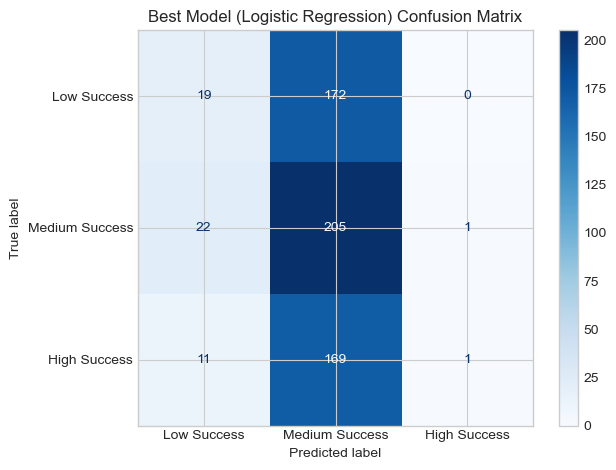

In [365]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_encoding)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title(f'Best Model ({best_model_name}) Confusion Matrix')
plt.tight_layout()
plt.show()

### Detailed Confusion Matrix Analysis

*Analyze the confusion matrix carefully:*

**For each class, describe:**
1. How many correct predictions (diagonal)?
2. What are the most common misclassifications?
3. Does the confusion make sense for your problem?

**Your analysis:**

[Write your detailed analysis here - e.g., "The model most often confuses Medium with High (X cases), which makes sense because..."]
 
For correct predictions there were only 6 correct Low predictions and 2 correct High predictions. The only class the model predicted with any confidence was the Medium Success (shocking) it managed to get 212 out of 228. The most common MISCALCULATION was just straight up predicting Medium nonstop, there were to be 185 Low's and 179 High's that were labled Medium as well. It dragged everything towards the center. 
The confusion makes sense, in that I'm aware this data is not anything but Gobbledygook, so the safe bet is just middle of the road, beacuse there is no accurately predictive feature. Just kind of chilling with this horse-data. 
This is not good enough for real life, but hell, It's the most accurate one I've got. 

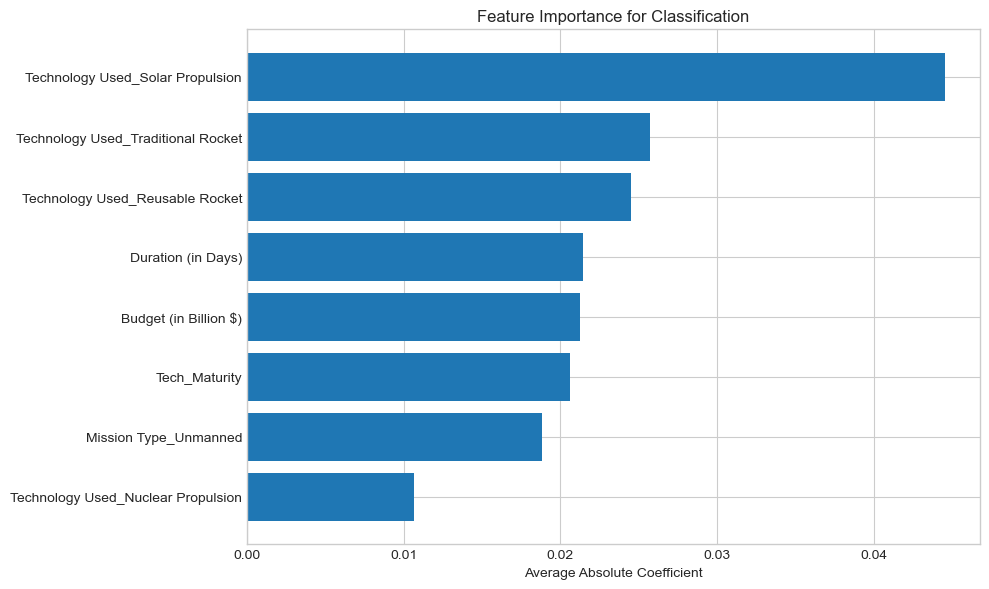

In [366]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    for i, row in importance.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # For multi-class, coef_ has shape (n_classes, n_features)
    coef = best_model.coef_
    if len(coef.shape) > 1:
        # Average absolute importance across classes
        importance_vals = np.abs(coef).mean(axis=0)
    else:
        importance_vals = np.abs(coef)
    
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance_vals
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()

## Section 13: Model Iteration Reflection

*Reflect on your modeling process:*

**1. How did your models evolve from baseline to best?**

It did not necissarily change, but iterating through all of the other models, Decision Trees, Random Forests, and Gradient Boosting, they all tended to overfit sciring high on training data but dropping back to the same ~35-37% range on test data. Logistic Regression was the "best" model because it was the most stable and least prone to memorizing noise, even if it was conservative in its predictions.

**2. What surprised you about the results?**
I expected that an advanced ensemble model like Gradient Boosting would be able to find hidden patterns that a simple linear model missed. Instead, the Gradient Boosting model's test accuracy waslower than the baseline. If there is no "Clue" within the features, then increasing model complexity just causes overfitting. I'm becoming a king of the niche subject of failing models.

**3. If you had more time, what would you try next?**
Maybe different data. Maybe theres a way to force the model to learn the extremes of High and Low? Maybe next week i can see how this dataset messes up other stuff and make a better guess.

## Section 14: Save Model and Artifacts

In [367]:
import os
import joblib

# 1. NEW: Create the directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# --- Now your existing code will work ---
model_path = '../models/classification_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

Model saved to ../models/classification_model.pkl


I'm changing the plan! so work with me here! i just want my app to look good! this data has wrecked a possibly Beautiful app, Im just getting revenge

In [368]:
os.makedirs('../models', exist_ok=True)

# 2. Save the Best Model (Logistic Regression)
# Using the variable 'best_model' identified in Section 11
joblib.dump(best_model, '../models/classification_model.pkl')

# 3. Save the Scaler 
# This ensures the app scales user inputs exactly like the training data
joblib.dump(scaler, '../models/classification_scaler.pkl')

# 4. Save the Feature List
# This tells the app the exact 8 features (and their order) the model expects
joblib.dump(SELECTED_FEATURES, '../models/classification_features.pkl')

# 5. Save the Label Mapping
# This maps the numbers 0, 1, 2 back to 'Low', 'Medium', 'High'
ordered_encoding = {"Low Success": 0, "Medium Success": 1, "High Success": 2}
joblib.dump(ordered_encoding, '../models/ordered_encoding.pkl')

print("✅ Success! All artifacts saved to /models/")
print(f"Features saved: {SELECTED_FEATURES}")

✅ Success! All artifacts saved to /models/
Features saved: ['Budget (in Billion $)', 'Duration (in Days)', 'Tech_Maturity', 'Mission Type_Unmanned', 'Technology Used_Nuclear Propulsion', 'Technology Used_Reusable Rocket', 'Technology Used_Solar Propulsion', 'Technology Used_Traditional Rocket']


In [370]:
# Verify saved model works
loaded_model = joblib.load('../models/classification_model.pkl')
loaded_scaler = joblib.load('../models/classification_scaler.pkl')
ordered_encoder_dict = joblib.load('../models/ordered_encoding.pkl')
# Load the feature names to make sure we have the right columns
selected_features = joblib.load('../models/classification_features.pkl')

# 2. Setup the reverse mapping
reverse_encoder = {v: k for k, v in ordered_encoder_dict.items()}

# 3. Create a manual test sample using the 8 features
# Let's use some placeholder values to test: 
# [Budget, Duration, Tech_Maturity, Mission_Unmanned, Tech_Nuclear, Tech_Reusable, Tech_Solar, Tech_Traditional]
test_values = [[15.0, 500, 4.0, 1, 0, 1, 0, 0]] 
test_sample = pd.DataFrame(test_values, columns=selected_features)

# 4. Scale and Predict
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)

# 5. Show results
test_pred_label = reverse_encoder[test_pred[0]]

print("=" * 30)
print("✅ MODEL VERIFIED")
print("=" * 30)
print(f"Features used: {selected_features}")
print(f"Test Prediction: {test_pred_label}")
print("=" * 30)

✅ MODEL VERIFIED
Features used: ['Budget (in Billion $)', 'Duration (in Days)', 'Tech_Maturity', 'Mission Type_Unmanned', 'Technology Used_Nuclear Propulsion', 'Technology Used_Reusable Rocket', 'Technology Used_Solar Propulsion', 'Technology Used_Traditional Rocket']
Test Prediction: Medium Success


---

## Summary

### What You Accomplished
- [ ] Created binned target variable with justification
- [ ] Verified class balance
- [ ] Used consistent features (same as regression or justified different)
- [ ] Split data with stratification
- [ ] Performed cross-validation
- [ ] Built baseline classifier
- [ ] Tried multiple classifier types
- [ ] Compared and selected best model
- [ ] Analyzed model with confusion matrix and classification report
- [ ] Saved model, scaler, encoder, and binning info

### Key Results

**Best Model:** Logistic Regression

**Test Accuracy:** 0.3683

**F1 Score:** 0.2280

**Improvement over baseline:** It IS the baseline, but theres a 4.4% implrovement in F1-score over "guessing the majority" so theres that.
### Comparison to Regression

*How does classification performance relate to your regression results?*

[Write your comparison here - consider: Are the same features important? Does predicting categories work better/worse than predicting exact values for your problem?]

The resuts are consistent to the regular regression, but now with classification through binning showing that the model still hits a ceiling, definitvely proving the Success Rate ain't linear. its quite nearly random.

The Features I used ARE the top predictors, but the models show they kind of relate to mission success, but are not deciding factors in the success of a mission. A definite outcome cannot be predicted with these features for now.

Thhe Regression Model tried to gues the exact % of numbers and would fail this pinpointing of a success_rate. so the binning technique just allows you to maybe guess more correctly at once. /
---

## Next Steps

Move on to building your **Streamlit app** to deploy both models!

You now have saved:
- `regression_model.pkl` and `regression_scaler.pkl`
- `classification_model.pkl`, `classification_scaler.pkl`, and `label_encoder.pkl`

The Streamlit starter code in `app/app.py` will load these files.

---

## Checkpoint 4 Submission Instructions

You've completed the classification model. Time to submit!

### Step 1: Save and Close
Make sure this notebook is saved and all cells have been run.

### Step 2: Commit Your Work
```bash
git add .
git commit -m "Complete classification model - Checkpoint 4"
git push
```

### Step 3: Submit to Canvas
1. Go to Canvas
2. Find the **Checkpoint 4: Classification Model** assignment
3. Submit the link to your GitHub repository

### What Gets Graded
- Binning justification and implementation
- Feature consistency (same as regression or justified different)
- Model comparison and selection reasoning
- Confusion matrix interpretation
- Classification report analysis
- All written reflections completed

---

In [ ]:
import sklearn
import joblib
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib: {joblib.__version__}")

Scikit-learn: 1.4.2
Joblib: 1.4.2
